Number of Monte Carlo PDE points: 1000
Relative L2 error: 5.242546e-04
Max absolute error: 7.816404e-05

Additional Error Metrics
RMSE                : 3.328679e-05
Mean absolute error : 2.260000e-05


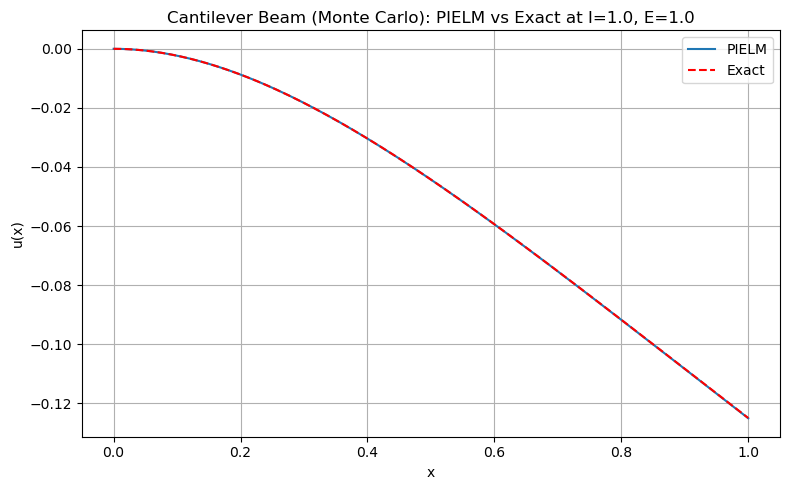

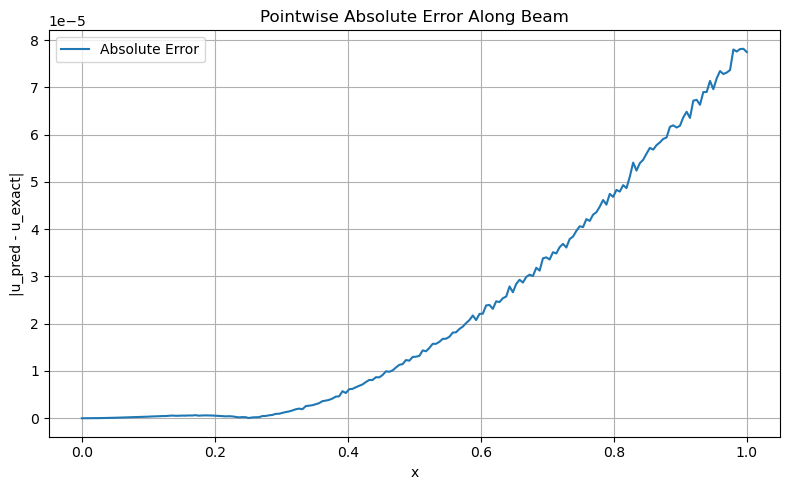

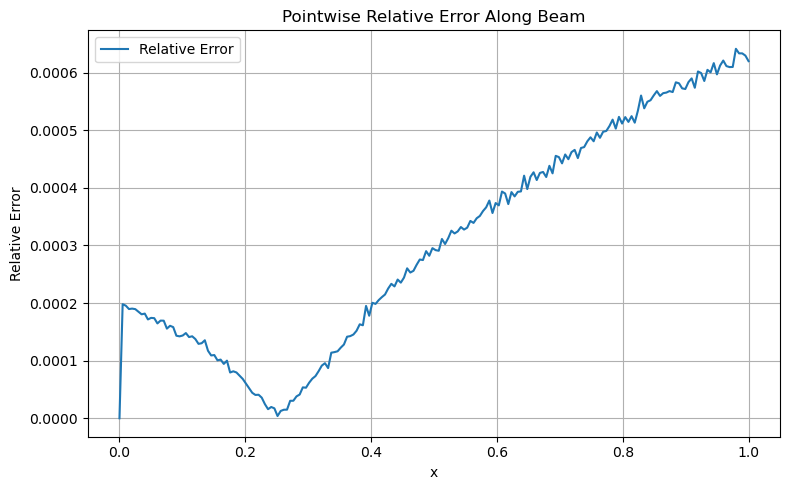

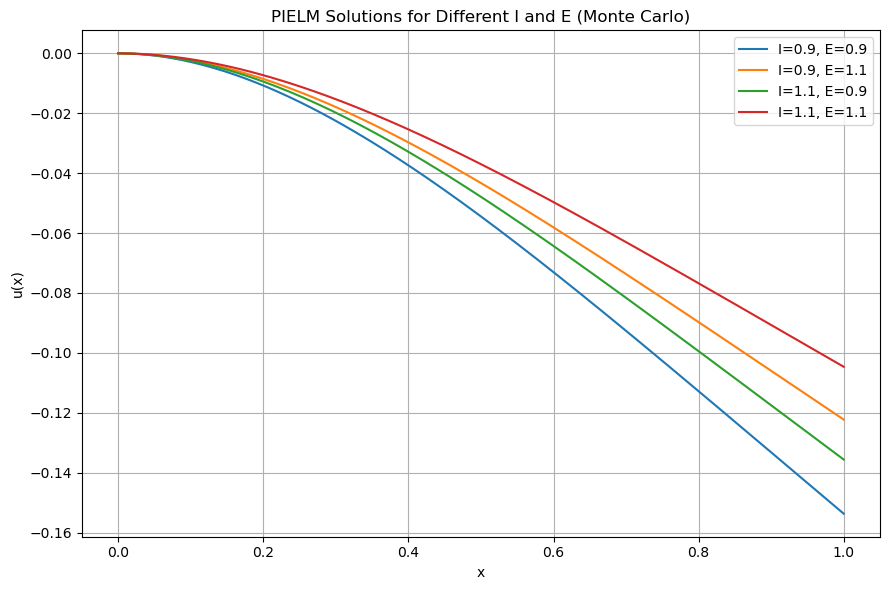

In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Beam problem
# Governing equation:
#     E*I*u_xxxx = q
# Example: cantilever beam with uniform load q
# BCs:
#     u(0)=0, u'(0)=0, u''(L)=0, u'''(L)=0
# =========================================================

L = 1.0
q = -1.0

# Uncertain parameter ranges
I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

# =========================================================
# Exact solution for cantilever beam under uniform load
# u(x) = q*x^2*(6L^2 - 4Lx + x^2)/(24EI)
# =========================================================
def exact_solution(x, I, E):
    return q * x**2 * (6*L**2 - 4*L*x + x**2) / (24 * E * I)

# =========================================================
# Monte Carlo Sampling
# =========================================================
def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

# =========================================================
# ELM setup
# Input = (x, I, E)
# =========================================================
hidden_size = 150
input_dim = 3

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b)**2)

# =========================================================
# Trial solution
# Use x^2 so that u(0)=0 and u'(0)=0 automatically
# =========================================================
def trial_features(X):
    x = X[:, 0:1]
    return (x**2) * hidden_layer(X)

# =========================================================
# Solve PIELM using Monte Carlo points
# =========================================================
def solve_pielm_mc(
    n_pde=1000,
    n_bc_param=100,
    lambda_bc=50.0,
    reg=1e-6
):
    # -----------------------------------------------------
    # PDE collocation points: Monte Carlo in (x, I, E)
    # -----------------------------------------------------
    mc_pde = monte_carlo_sampling(n_pde, 3)

    x_pde = mc_pde[:, 0:1] * L
    I_pde = mc_pde[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
    E_pde = mc_pde[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]

    X_pde = torch.cat([x_pde, I_pde, E_pde], dim=1).requires_grad_(True)

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_pde, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        grad4 = autograd.grad(uj_xxx.sum(), X_pde, create_graph=True)[0]
        uj_xxxx = grad4[:, 0:1]

        I_vals = X_pde[:, 1:2]
        E_vals = X_pde[:, 2:3]

        A_cols.append(E_vals * I_vals * uj_xxxx)

    A = torch.hstack(A_cols)
    b_pde = torch.full((X_pde.shape[0], 1), q)

    # -----------------------------------------------------
    # Boundary condition points at x=L using Monte Carlo in (I,E)
    # u''(L)=0, u'''(L)=0
    # -----------------------------------------------------
    mc_bc = monte_carlo_sampling(n_bc_param, 2)

    x_bc = torch.full((n_bc_param, 1), L)
    I_bc = mc_bc[:, 0:1] * (I_range[1] - I_range[0]) + I_range[0]
    E_bc = mc_bc[:, 1:2] * (E_range[1] - E_range[0]) + E_range[0]

    X_bc = torch.cat([x_bc, I_bc, E_bc], dim=1).requires_grad_(True)

    U_bc = trial_features(X_bc)

    C1_cols = []
    C2_cols = []

    for j in range(hidden_size):
        uj = U_bc[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_bc, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_bc, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_bc, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        C1_cols.append(uj_xx)
        C2_cols.append(uj_xxx)

    C1 = torch.hstack(C1_cols)
    C2 = torch.hstack(C2_cols)

    d1 = torch.zeros((X_bc.shape[0], 1))
    d2 = torch.zeros((X_bc.shape[0], 1))

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    # -----------------------------------------------------
    # KKT system
    # -----------------------------------------------------
    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints,
                      hidden_size + n_constraints)

    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_bc * C_T
    KKT[hidden_size:, :hidden_size] = lambda_bc * C

    rhs = torch.vstack([A_T @ b_pde, lambda_bc * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta, X_pde

# =========================================================
# Train
# =========================================================
beta, X_train = solve_pielm_mc(
    n_pde=1000,
    n_bc_param=100,
    lambda_bc=50.0,
    reg=1e-6
)

print("Number of Monte Carlo PDE points:", X_train.shape[0])

def predict(X):
    return trial_features(X) @ beta

# =========================================================
# Compare predicted and exact at selected values
# =========================================================
I_test = 1.0
E_test = 1.0

x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
I_plot = torch.full_like(x_plot, I_test)
E_plot = torch.full_like(x_plot, E_test)

X_test = torch.cat([x_plot, I_plot, E_plot], dim=1)

u_pred = predict(X_test).detach().squeeze()
u_exact = exact_solution(x_plot, I_plot, E_plot).detach().squeeze()

rel_l2_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
max_abs_error = torch.max(torch.abs(u_pred - u_exact))

print(f"Relative L2 error: {rel_l2_error.item():.6e}")
print(f"Max absolute error: {max_abs_error.item():.6e}")

# =========================================================
# Detailed Error Analysis
# =========================================================
abs_error = torch.abs(u_pred - u_exact)
eps = 1e-12
rel_error_pointwise = abs_error / (torch.abs(u_exact) + eps)
rmse = torch.sqrt(torch.mean((u_pred - u_exact)**2))
mean_abs_error = torch.mean(abs_error)

print("\nAdditional Error Metrics")
print(f"RMSE                : {rmse.item():.6e}")
print(f"Mean absolute error : {mean_abs_error.item():.6e}")

# =========================================================
# Plot comparison
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), u_pred.numpy(), label="PIELM")
plt.plot(x_plot.numpy(), u_exact.numpy(), "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(f"Cantilever Beam (Monte Carlo): PIELM vs Exact at I={I_test}, E={E_test}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot Absolute Error
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), abs_error.numpy(), label="Absolute Error")
plt.xlabel("x")
plt.ylabel("|u_pred - u_exact|")
plt.title("Pointwise Absolute Error Along Beam")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Plot Relative Error
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), rel_error_pointwise.numpy(), label="Relative Error")
plt.xlabel("x")
plt.ylabel("Relative Error")
plt.title("Pointwise Relative Error Along Beam")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Compare displacement variation for different I,E
# =========================================================
cases = [
    (0.9, 0.9),
    (0.9, 1.1),
    (1.1, 0.9),
    (1.1, 1.1),
]

plt.figure(figsize=(9, 6))
for I_case, E_case in cases:
    I_case_vec = torch.full_like(x_plot, I_case)
    E_case_vec = torch.full_like(x_plot, E_case)
    X_case = torch.cat([x_plot, I_case_vec, E_case_vec], dim=1)
    u_case = predict(X_case).detach().squeeze()
    plt.plot(x_plot.numpy(), u_case.numpy(), label=f"I={I_case}, E={E_case}")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PIELM Solutions for Different I and E (Monte Carlo)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()